# Hierarchical clustering

Agglomerative hierarchical clustering of the phosphosite temporal profiles, as an
alternative to the KMeans workflow in `Clustering.ipynb`. Same data, same column
selection, same filtering — only the clustering model changes, so the two results
are directly comparable (the last section computes the ARI between them).

## Why this notebook exists, and what it does that KMeans cannot

KMeans returns a flat list of labels: *k* is decided up front, the result depends on
the random seed, and the clusters have no relationship to each other. Hierarchical
clustering instead builds the **entire merge tree** once, deterministically, and
"how many clusters" becomes a question you answer *afterwards* by cutting that tree.

Three practical consequences, which structure this notebook:

1. **The k-scan is nearly free.** Every k is one `fcluster()` call on the tree that
   was already built, instead of a full model refit (times several seeds) per k.

2. **QC is about the tree, not the seed.** Nothing here is random, so seed-stability
   is meaningless. The questions that matter are instead: does the tree faithfully
   represent the real distances (*cophenetic correlation*), where are the big jumps
   in merge distance (*the hierarchical elbow*), and does one giant cluster swallow
   the dataset (the classic failure mode of `average`/`single` linkage)?

3. **Merging is exact and principled.** Every cluster produced by a cut *is* a node
   of the tree. So two clusters that sit under a common parent can be merged into
   exactly that parent — no re-clustering, no approximation, and no site changes
   cluster except by joining the union. This is the "look at the clusters, then
   constrain the result" loop, and it is the main reason to run this notebook.

   Note the contrast with `compute_centroid_linkage()` in the KMeans path: that
   function re-clusters the *centroids* to invent a hierarchy after the fact. Here
   the hierarchy **is** the model, so a merge is a statement the model actually
   supports.

All functions live in `src/hierarchical_clustering.py`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio

from sklearn.metrics import adjusted_rand_score

from src.column_spec import ColumnSpec
from src.hierarchical_clustering import *
from src.clustering import cluster_similarity_per_condition, consensus_stability
from src.plotting_functions import *
from src.filters import *

pio.renderers.default = "png"

In [3]:
hme1_2 = pd.read_csv("../../notebooks/03_clustering/Data_clustered/20260715_hTERT_HEM1_2_processed_phPlus_clustered_kinasepred.tsv",
                     sep       = "\t",
                     low_memory = False,)
print(f"Loaded: {hme1_2.shape[0]} sites x {hme1_2.shape[1]} columns")

Loaded: 8723 sites x 481 columns


## Parameters

Edit the cell below to change the dataset, conditions and cut settings.
All downstream cells read from these variables.

In [4]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the full analysis
# ════════════════════════════════════════════════════════════

df_raw = hme1_2                       # dataset to cluster

CELL_LINES   = ["WT"]                 # ["WT", "BRAFS151A", "GAB1Y259A"]
CONDITIONS   = ["_EGF_"]              # ["_EGF_", "_INS_", "_EGFnINS_"]
DATA_TYPE    = "log2:zscore"
EXCLUDE_FULL = True

# Filtering (kept identical to Clustering.ipynb so the two methods are comparable)
MIN_REPS = 2
MIN_FC   = 0.5                        # |log2FC| threshold (extremes mode)

# Tree construction
LINKAGE_METHOD = "ward"               # "ward" | "average" | "complete" | "weighted"
METRIC         = "euclidean"          # ward / centroid / median require euclidean

# k-scan
K_RANGE           = range(4, 31, 2)   # k values to test
SILHOUETTE_SAMPLE = 4000              # subsample for the silhouette (O(n^2) exact); None = all

# Final cut (set after inspecting the scan below)
K_FINAL = 12

# Constrained merging (set after looking at the cluster-level dendrogram)
MERGE_MAX_HEIGHT       = 25.0         # propose merging sibling pairs joining below this height
MERGE_MIN_CLUSTER_SIZE = None         # propose merging clusters smaller than this

# ── Derived — do not edit ────────────────────────────────────────────────────
_scan_cols   = ColumnSpec.select(df_raw,
                                 cell_lines            = CELL_LINES,
                                 data_type             = DATA_TYPE,
                                 conditions            = CONDITIONS,
                                 exclude_full          = EXCLUDE_FULL,
                                 exclude_replicate_cols = True,)
N_DIMS       = len(CELL_LINES) * len(CONDITIONS)
N_TIMEPOINTS = len(_scan_cols) // N_DIMS

_transform  = DATA_TYPE.replace(":", "_")
_conditions = "".join(c.strip("_") for c in CONDITIONS)
CLUSTER_COL = f"Hierarchical_{LINKAGE_METHOD}_{K_FINAL}_cluster_{'_'.join(CELL_LINES)}_{_conditions}_{_transform}"
MERGED_COL  = f"{CLUSTER_COL}_merged"

print(f"Columns selected: {len(_scan_cols)}  |  Dimensions: {N_DIMS}  |  Timepoints per condition: {N_TIMEPOINTS}")
print(f"Columns to be used for the clustering: {_scan_cols}")
print(f"\nCluster label column: {CLUSTER_COL}")

Columns selected: 6  |  Dimensions: 1  |  Timepoints per condition: 6
Columns to be used for the clustering: ['WT_log2:zscore_EGF_starve', 'WT_log2:zscore_EGF_2', 'WT_log2:zscore_EGF_5', 'WT_log2:zscore_EGF_10', 'WT_log2:zscore_EGF_15', 'WT_log2:zscore_EGF_90']

Cluster label column: Hierarchical_ward_12_cluster_WT_EGF_log2_zscore


# Filtering data

Identical to `Clustering.ipynb`: drop sites seen in too few replicates, then keep only
sites that actually move (|log2FC| above threshold at some timepoint). Filtering before
clustering matters more here than for KMeans — the linkage needs the full pairwise
distance matrix, which is `n*(n-1)/2` float64 values (~320 MB at 9000 sites) and grows
quadratically.

In [5]:
df_filtered = filter_by_nreps(df_raw, min_reps=MIN_REPS)
print(f"After n:reps >= {MIN_REPS}:  {df_filtered.shape[0]} sites")

df_filtered = filter_dynamics(df           = df_filtered,
                              cell_lines   = CELL_LINES,
                              conditions   = CONDITIONS,
                              data_type    = "log2:FC",
                              threshold    = MIN_FC,
                              mode         = "extremes",
                              exclude_full = EXCLUDE_FULL,)
print(f"After |FC| >= {MIN_FC}:      {df_filtered.shape[0]} sites")

After n:reps >= 2:  8723 sites
After |FC| >= 0.5:      8723 sites


## Building the tree

`build_feature_matrix()` selects the columns through `ColumnSpec`, reshapes them with
the same `reshape_df()` the KMeans path uses, and flattens the result — so the matrix
clustered here is byte-for-byte the one KMeans would see. Missing values are **dropped
and reported**, never filled with 0: `pdist` propagates a single NaN into every distance
touching that row, which would corrupt the whole tree.

The tree is built **once** in the next cell and reused by every scan, cut and merge below.

In [6]:
df_used, X, X_flat, cols, n_timepoints, n_dims = build_feature_matrix(df                 = df_filtered,
                                                                     cell_lines         = CELL_LINES,
                                                                     conditions         = CONDITIONS,
                                                                     data_type          = DATA_TYPE,
                                                                     exclude_full       = EXCLUDE_FULL,
                                                                     time_series_length = N_TIMEPOINTS,
                                                                     df_dimensions      = N_DIMS,
                                                                     transpose          = True,
                                                                     nan_policy         = "drop",
                                                                     verbose            = True,)

Column selection (6): ['WT_log2:zscore_EGF_starve', 'WT_log2:zscore_EGF_2', 'WT_log2:zscore_EGF_5', 'WT_log2:zscore_EGF_10', 'WT_log2:zscore_EGF_15', 'WT_log2:zscore_EGF_90']
Dimensions: 1 | Timepoints per condition: 6
Feature matrix: X (8723, 6, 1) -> flat (8723, 6)


In [7]:
Z = compute_linkage(X_flat,
                    method  = LINKAGE_METHOD,
                    metric  = METRIC,
                    verbose = True,)

Linkage built: method=ward, metric=euclidean, 8723 sites, merge heights 0.035 - 146.490


## Which linkage method? — cophenetic correlation

The **cophenetic distance** between two sites is the height at which they first end up in
the same cluster. The **cophenetic correlation** is the Pearson correlation between those
tree distances and the true pairwise distances — i.e. how much the dendrogram distorts the
real distance structure. It is the one number that judges the *tree itself* rather than a
particular cut:

| value | reading |
|-------|---------|
| > 0.8   | the tree is a good summary of the distance structure |
| 0.6–0.8 | usable, but some relationships are distorted |
| < 0.6   | the hierarchy is misleading — prefer a partitional method |

**Do not read it alone.** It rewards methods that compress distances (`average` almost
always wins on this metric by construction), so the table below also reports
`largest_cluster_frac`: a method that puts most of the dataset in one cluster is useless
here whatever its cophenetic correlation says. `ward` is the sensible default — it
minimises the same within-cluster variance KMeans does, which makes the two methods
comparable, and it resists chaining.

In [8]:
linkage_comparison, trees = compare_linkage_methods(X_flat,
                                                    methods           = ("ward", "average", "complete", "weighted"),
                                                    metric            = METRIC,
                                                    k_reference       = K_FINAL,
                                                    silhouette_sample = SILHOUETTE_SAMPLE,
                                                    random_state      = 0,
                                                    verbose           = True,)
linkage_comparison

  method  cophenetic_corr  silhouette_k12  largest_cluster_frac  n_singletons  n_clusters_obtained
 average         0.760161        0.212714              0.491345             1                   12
    ward         0.705093        0.132015              0.194314             0                   12
weighted         0.639995        0.073727              0.566434             0                   12
complete         0.522314        0.125489              0.200390             0                   12


,method,cophenetic_corr,silhouette_k12,largest_cluster_frac,n_singletons,n_clusters_obtained
0,average,0.760161,0.212714,0.491345,1,12
1,ward,0.705093,0.132015,0.194314,0,12
2,weighted,0.639995,0.073727,0.566434,0,12
3,complete,0.522314,0.125489,0.200390,0,12


## Where to cut — the hierarchical elbow

Reading right to left, each agglomeration step merges two clusters. A **large jump in
merge distance** means the two things joined at that step were far apart, so the partition
*before* that merge was capturing real separation. The number of clusters just before the
largest jump is the k the tree itself suggests.

The right panel plots the differences between consecutive merge distances, which makes
that jump far easier to see than eyeballing the raw curve.

**Caveat — the printed suggestion is usually too small.** The biggest gap in absolute terms
almost always sits at the very top of the tree, where the last two or three super-clusters
join, so the heuristic tends to return k = 2–4. That is a real statement (the coarsest split
is the strongest one), but it is not the resolution you want for downstream biology. Read
the *local* structure of the plot instead: look for the largest bar within the k range you
are actually considering, and cross-check it against the silhouette and the size
distribution in the k-scan below.

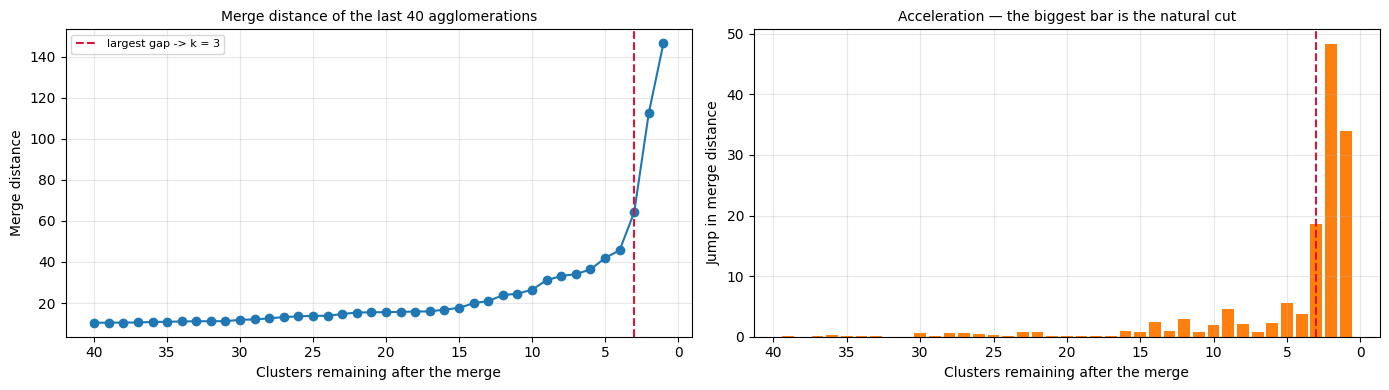

Largest gap in the last 40 merges suggests k = 3


In [9]:
fig, axes, suggested_k = plot_merge_distances(Z,
                                              last_n  = 40,
                                              figsize = (14, 4),)
plt.show()
print(f"Largest gap in the last 40 merges suggests k = {suggested_k}")

## k-scan — scoring every cut of the same tree

Because the tree already exists, each k costs one `fcluster()` call. Metrics reported:

- **Inertia** — within-cluster sum of squares (what KMeans minimises, so this number is
  directly comparable to the KMeans run). Monotonically decreasing; look for the elbow.
- **Silhouette** — mean `(b − a) / max(a, b)`; higher is better. Subsampled by default
  because the exact computation is O(n²). **0.2–0.4 is a normal range for
  phosphoproteomics** — do not expect 0.7.
- **Calinski-Harabasz** — between/within variance ratio; higher is better.
- **Davies-Bouldin** — mean worst-case cluster overlap; **lower** is better.
- **Merge height** — the tree distance at which k would collapse to k−1. High = the k
  clusters are well separated.
- **Size distribution** — largest-cluster fraction and singleton count.

**Read the size-distribution panel first.** Hierarchical methods can reach a flattering
silhouette by shaving off a handful of tiny outlier clusters while one cluster keeps
almost everything. That is not a partition, whatever the other metrics say.

In [10]:
scan_df = hierarchical_kscan(Z                 = Z,
                             X_flat            = X_flat,
                             k_range           = K_RANGE,
                             silhouette_sample = SILHOUETTE_SAMPLE,
                             random_state      = 0,
                             verbose           = True,)
scan_df

k=  4  inertia=  13243.66  sil=0.2458  CH=   4198.0  DB=1.135  largest=47.94%  min_size=850
k=  6  inertia=  11320.11  sil=0.1843  CH=   3242.4  DB=1.745  largest=24.74%  min_size=661
k=  8  inertia=  10079.10  sil=0.1762  CH=   2753.8  DB=1.560  largest=24.27%  min_size=125
k= 10  inertia=   9044.52  sil=0.1505  CH=   2497.1  DB=1.486  largest=19.43%  min_size=125
k= 12  inertia=   8391.78  sil=0.1320  CH=   2263.1  DB=1.519  largest=19.43%  min_size=125
k= 14  inertia=   7888.22  sil=0.1326  CH=   2079.4  DB=1.555  largest=19.43%  min_size=125
k= 16  inertia=   7534.10  sil=0.1103  CH=   1913.7  DB=1.615  largest=11.89%  min_size=78
k= 18  inertia=   7265.72  sil=0.0988  CH=   1769.5  DB=1.673  largest=10.98%  min_size=78
k= 20  inertia=   7016.60  sil=0.0833  CH=   1655.3  DB=1.715  largest=10.98%  min_size=78
k= 22  inertia=   6775.48  sil=0.0830  CH=   1565.4  DB=1.774  largest=8.77%  min_size=78
k= 24  inertia=   6549.76  sil=0.0850  CH=   1491.2  DB=1.778  largest=8.77%  min_siz

,k,n_clusters_obtained,inertia,silhouette,calinski_harabasz,davies_bouldin,merge_height,largest_cluster_frac,min_cluster_size,n_singletons
0,4,4,13243.660503,0.245813,4198.016735,1.135159,45.724611,0.479422,850,0
1,6,6,11320.113510,0.184349,3242.381359,1.745443,36.366133,0.247392,661,0
2,8,8,10079.097470,0.176207,2753.845969,1.559877,33.191016,0.242692,125,0
3,10,10,9044.520267,0.150509,2497.075581,1.486040,26.490445,0.194314,125,0
4,12,12,8391.779477,0.132015,2263.069952,1.518685,23.837507,0.194314,125,0
5,14,14,7888.221114,0.132595,2079.444660,1.555188,19.956867,0.194314,125,0
6,16,16,7534.103607,0.110342,1913.741327,1.614689,16.846989,0.118881,78,0
7,18,18,7265.717310,0.098813,1769.482436,1.672908,15.865501,0.109825,78,0
8,20,20,7016.600274,0.083320,1655.317747,1.715404,15.562770,0.109825,78,0
9,22,22,6775.479313,0.083025,1565.354982,1.773687,15.387298,0.087699,78,0


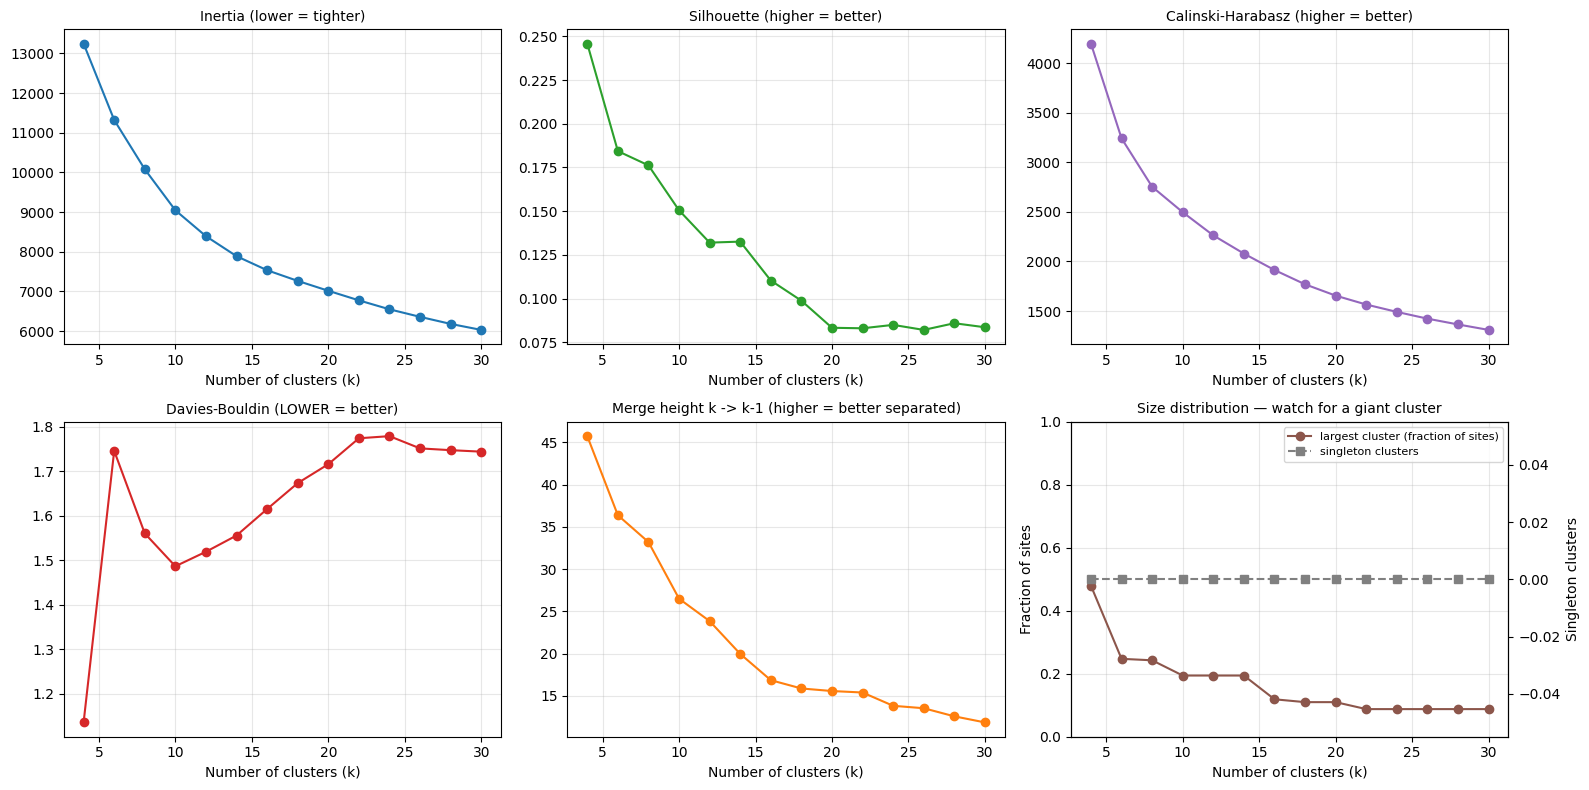

In [11]:
fig, axes = plot_hierarchical_scan(scan_df,
                                   figsize = (16, 8),)
plt.show()

## The tree itself

Plotting ~9000 leaves is unreadable, so the dendrogram is truncated to its top nodes;
each leaf label shows how many original sites the collapsed branch contains. Set
`color_threshold` to the merge height of your intended cut to preview that partition
(the k-scan reports `merge_height` per k).

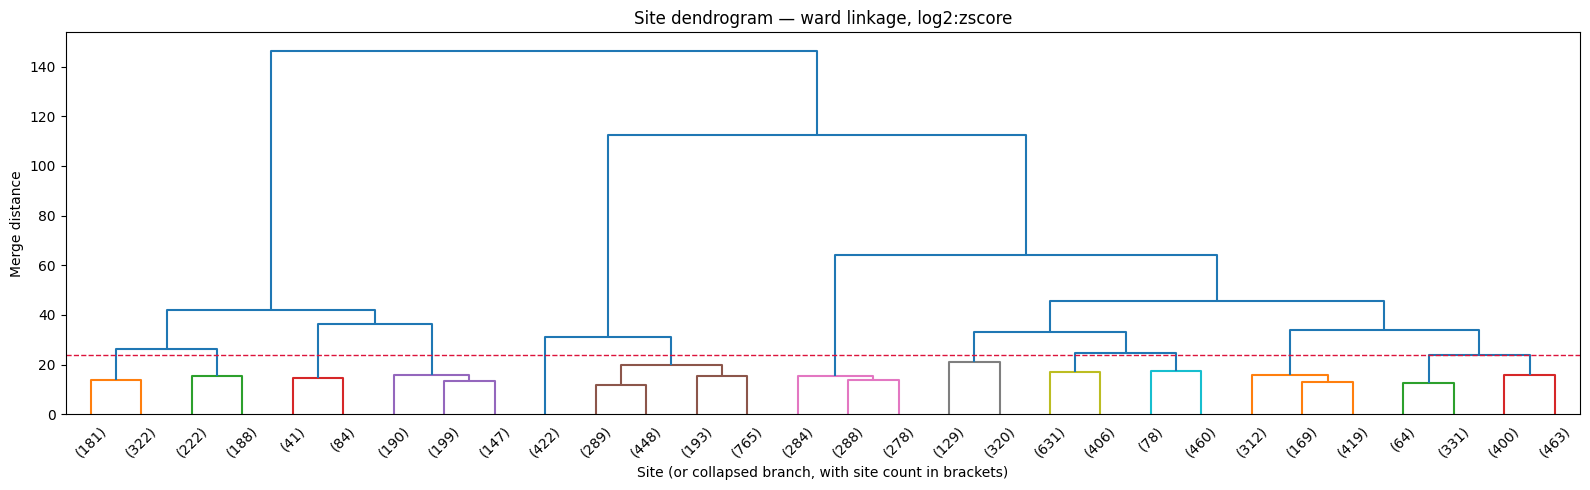

Red line = merge height at which k=12 collapses to k=11: 23.8375068181809


In [12]:
_cut_height = float(scan_df.loc[scan_df["k"] == K_FINAL, "merge_height"].iloc[0]) \
              if (scan_df["k"] == K_FINAL).any() else None

fig, ax = plot_site_dendrogram(Z,
                               color_threshold = _cut_height,
                               truncate_p      = 30,
                               figsize         = (16, 5),
                               title           = f"Site dendrogram — {LINKAGE_METHOD} linkage, {DATA_TYPE}",)
plt.show()
print(f"Red line = merge height at which k={K_FINAL} collapses to k={K_FINAL - 1}: {_cut_height}")

## Final clustering

Set `K_FINAL` in the Parameters cell after inspecting the scan, then run this section.
`precomputed_Z=Z` re-cuts the tree already built above instead of recomputing the linkage
— re-cutting is free, rebuilding is not.

Labels are renumbered **by decreasing cluster size** (cluster 0 is always the largest),
because `fcluster`'s own numbering is arbitrary and changes with every cut.

In [13]:
result = hierarchical_clustering(df_to_cluster            = df_used.copy(),
                                 data_type                = DATA_TYPE,
                                 condition_for_clustering = CONDITIONS,
                                 cell_lines               = CELL_LINES,
                                 exclude_full             = EXCLUDE_FULL,
                                 df_dimensions            = N_DIMS,
                                 time_series_length       = N_TIMEPOINTS,
                                 cluster_column_name      = CLUSTER_COL,
                                 number_of_clusters       = K_FINAL,
                                 linkage_method           = LINKAGE_METHOD,
                                 metric                   = METRIC,
                                 transpose                = True,
                                 precomputed_Z            = Z,
                                 verbose                  = True,)

df_clustered = result.df

Column selection (6): ['WT_log2:zscore_EGF_starve', 'WT_log2:zscore_EGF_2', 'WT_log2:zscore_EGF_5', 'WT_log2:zscore_EGF_10', 'WT_log2:zscore_EGF_15', 'WT_log2:zscore_EGF_90']
Dimensions: 1 | Timepoints per condition: 6
Feature matrix: X (8723, 6, 1) -> flat (8723, 6)

Cut: criterion=maxclust, value=12 -> 12 clusters
Cluster sizes:
0     1695
1     1258
2     1037
3      900
4      850
5      538
6      536
7      503
8      449
9      422
10     410
11     125
dtype: int64


## Cluster quality control

Four complementary views. None of them is decisive alone — together they tell you which
clusters to trust, and which are candidates for the merging step further down.

### 1. Per-cluster silhouette — *which* clusters are weak

The global silhouette is one number for the whole partition and hides the interesting
case: several clean clusters plus one incoherent one. A cluster with mean silhouette near
0 (or negative) overlaps its neighbours; `frac_negative` is the fraction of its sites that
would be better placed in another cluster. Worst clusters are listed first — these are the
prime merge candidates.

In [14]:
sil_table = silhouette_per_cluster(X_flat      = result.X_flat,
                                   labels      = result.labels,
                                   sample_size = SILHOUETTE_SAMPLE,
                                   random_state = 0,)
sil_table

,cluster,n_sites,mean_silhouette,median_silhouette,frac_negative
0,8,188,-0.032672,-0.051028,0.595745
1,1,580,0.018421,0.025010,0.456897
2,10,180,0.057252,0.079843,0.388889
3,11,47,0.104020,0.086322,0.234043
4,0,798,0.123197,0.151769,0.271930
5,5,236,0.128481,0.143674,0.177966
6,3,407,0.134128,0.165592,0.221130
7,6,228,0.145230,0.185514,0.210526
8,2,488,0.177189,0.199307,0.116803
9,4,415,0.217390,0.236069,0.127711


### 2. Nearest-centroid agreement

Hierarchical clustering never checks whether a site is closest to its own cluster's
centroid — placement comes from the merge history of its neighbourhood. Low agreement
means the clusters are not compact blobs.

This number matters beyond aesthetics: it is exactly the disagreement that a
**nearest-centroid transfer to the mutant datasets** would inherit (the transfer route
prototyped in `Clustering_mutant_cell_lines.ipynb`). If agreement is low, cluster identity
is not something a centroid can carry across datasets.

In [15]:
agreement, agreement_per_cluster = assignment_agreement(distances = result.distances_to_centroids,
                                                        labels    = result.labels,)
print(f"Overall nearest-centroid agreement: {agreement:.1%}\n")
print(agreement_per_cluster.round(3))

Overall nearest-centroid agreement: 78.7%

cluster
0     0.770
1     0.626
2     0.814
3     0.798
4     0.881
5     0.743
6     0.868
7     0.897
8     0.655
9     0.986
10    0.776
11    0.952
dtype: float64


### 3. Within-cluster dispersion per condition

Reuses `cluster_similarity_per_condition()` from `src/clustering.py` — the same metric
used for the KMeans clusters, so the bars are comparable between the two notebooks.
Lower = tighter.

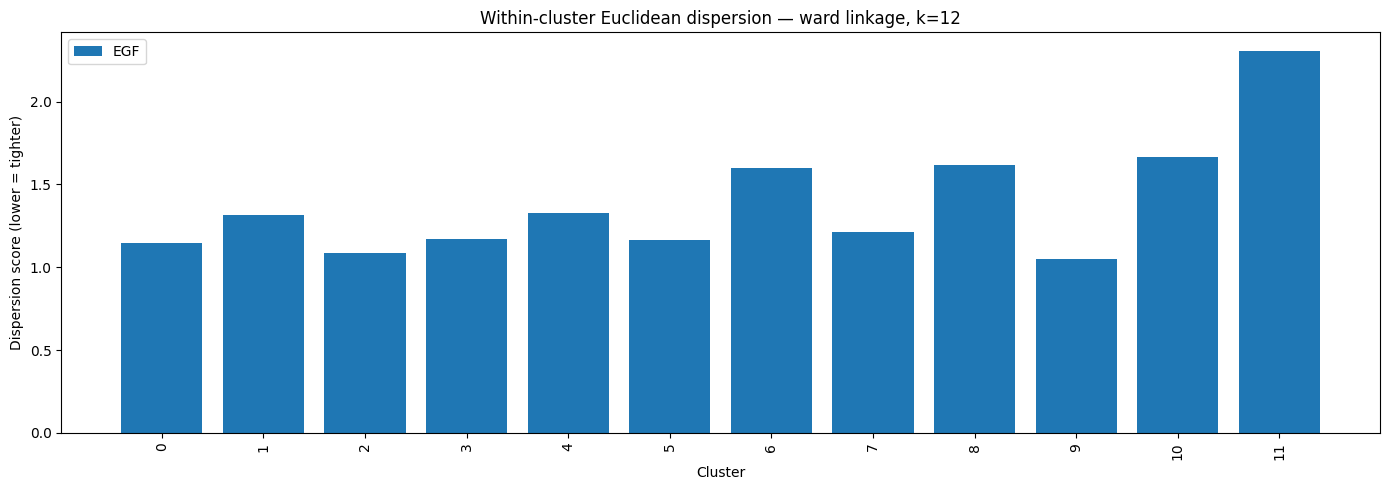

In [16]:
scores = cluster_similarity_per_condition(df                  = df_clustered,
                                          cell_lines          = CELL_LINES,
                                          conditions          = CONDITIONS,
                                          data_type           = DATA_TYPE,
                                          cluster_column_name = CLUSTER_COL,
                                          exclude_full        = EXCLUDE_FULL,
                                          transpose           = True,)

fig, ax = plot_cluster_scores(scores,
                              cond_order = [c.strip("_") for c in CONDITIONS],
                              title      = f"Within-cluster Euclidean dispersion — {LINKAGE_METHOD} linkage, k={K_FINAL}",)
plt.show()

### 4. Assignment confidence

`result.distances_to_centroids` plays the same role as the `barycenters` matrix of the
KMeans path, so `plot_cluster_assignment_qc()` can be reused directly:

- **Distance heatmap** — rows are sites sorted by cluster; the assigned cluster should be
  the darkest cell in each row.
- **UMAP** of the distance-to-centroid matrix, coloured by cluster.
- **Margin histogram** — (2nd-best − best) distance; higher = more confident.
- **Margin per cluster** — which clusters are internally tight vs ambiguous.

Caveat specific to this notebook: since hierarchical clustering does not assign by
centroid, a negative margin is possible and simply reflects the disagreement measured
above — it is not a bug.

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


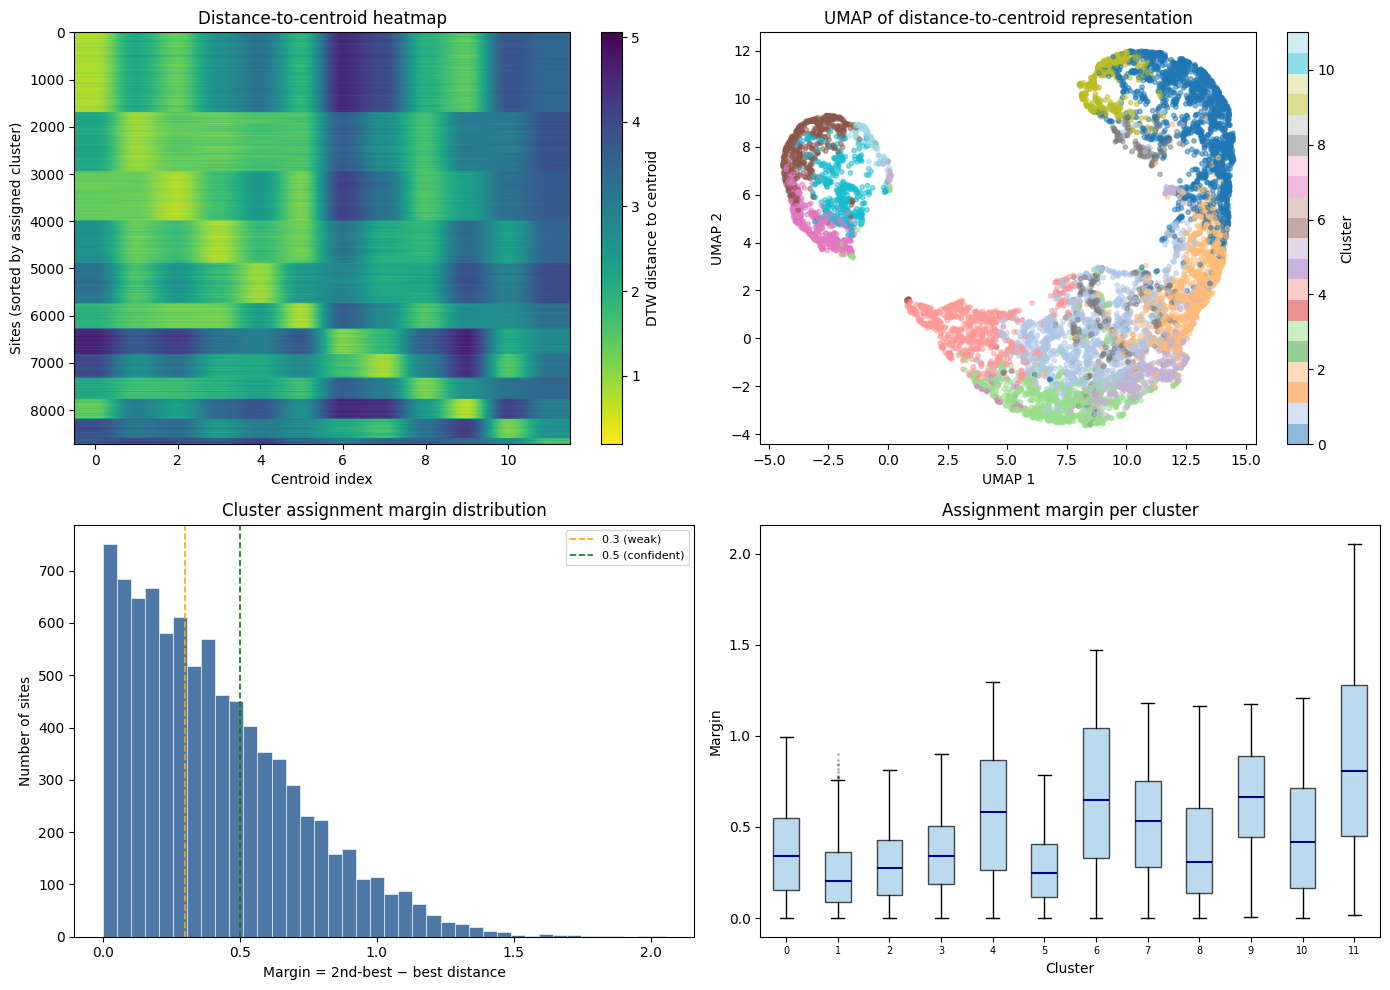

In [17]:
fig, axes = plot_cluster_assignment_qc(result.distances_to_centroids,
                                       result.labels,)
plt.show()

### 5. Bootstrap stability (optional — slower)

`ward` linkage is deterministic, so re-running it with a different seed changes nothing
and seed-stability is meaningless. The meaningful question is stability **to the sample**:
cluster random 80% subsets and measure how often pairs of sites stay together (ARI).

This reuses `consensus_stability()` from `src/clustering.py` with `bootstrap=True`; the
wrapper ignores the `seed` argument because the method is deterministic — the variation
comes entirely from the resampling. Roughly a few seconds per run at this dataset size.

In [18]:
# def _hierarchical_cluster_fn(sub_df, seed):
#     # Cluster a bootstrap subsample; `seed` is unused because ward is deterministic.
#     sub_result = hierarchical_clustering(df_to_cluster            = sub_df.copy(),
#                                          data_type                = DATA_TYPE,
#                                          condition_for_clustering = CONDITIONS,
#                                          cell_lines               = CELL_LINES,
#                                          exclude_full             = EXCLUDE_FULL,
#                                          df_dimensions            = N_DIMS,
#                                          time_series_length       = N_TIMEPOINTS,
#                                          cluster_column_name      = "_tmp",
#                                          number_of_clusters       = K_FINAL,
#                                          linkage_method           = LINKAGE_METHOD,
#                                          metric                   = METRIC,
#                                          verbose                  = False,)
#     return sub_result.labels
#
# stability = consensus_stability(df                          = df_used,
#                                 cluster_fn                  = _hierarchical_cluster_fn,
#                                 n_runs                      = 10,
#                                 bootstrap                   = True,
#                                 bootstrap_frac              = 0.8,
#                                 compute_coassociation       = False,   # O(n^2) memory at this size
#                                 reference_labels            = result.labels,
#                                 random_state                = 0,
#                                 verbose                     = True,)
# print(f"Mean pairwise ARI across bootstrap runs: {stability['mean_ari']:.3f}")

## Cluster visualisation

Grey lines are individual sites, the coloured line is the cluster mean.

 Plot not saved


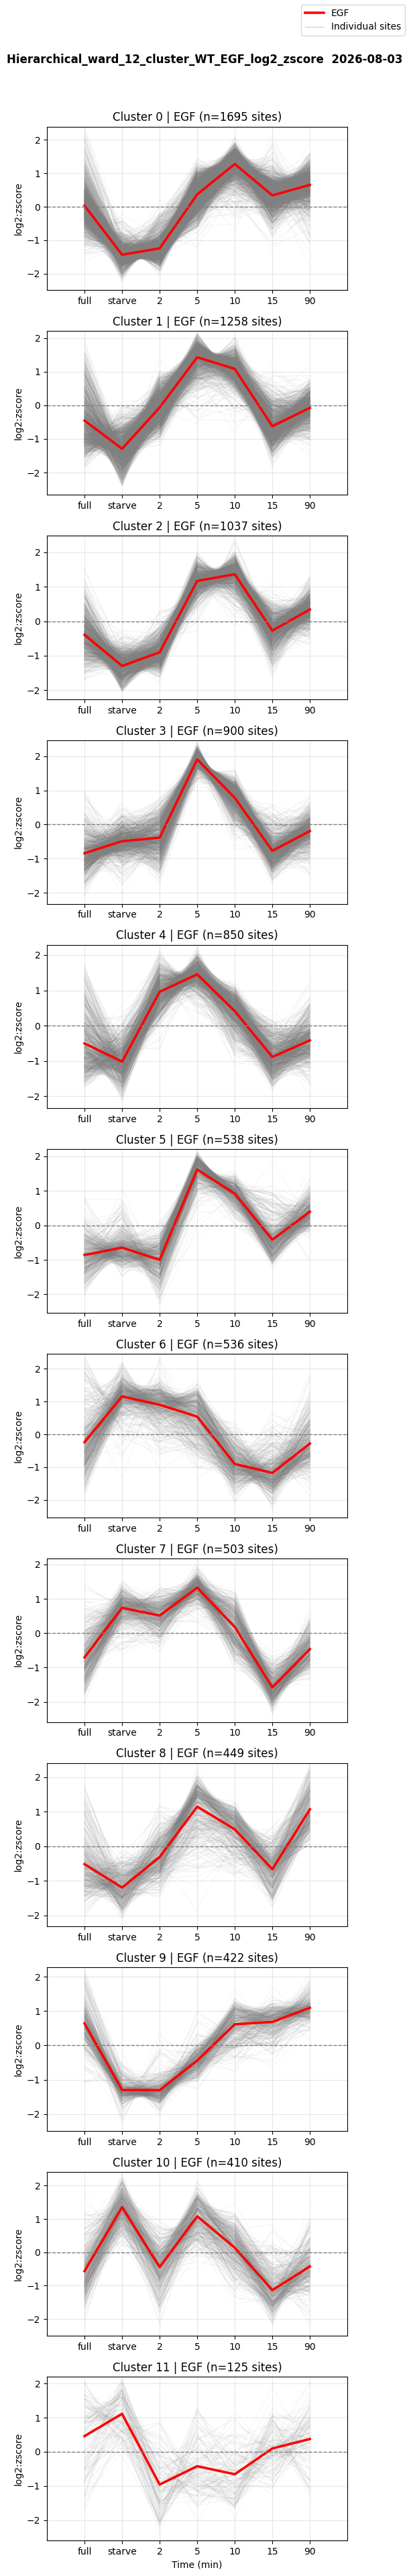

In [19]:
clusters_plot_linear_mutants(df                  = df_clustered,
                             cluster_column      = CLUSTER_COL,
                             data_type           = DATA_TYPE,
                             cell_lines          = CELL_LINES,
                             conditions          = CONDITIONS,
                             colors              = {"_EGF_": "red", "_INS_": "blue", "_EGFnINS_": "fuchsia"},
                             panel_by            = "condition",
                             plot_different_data = True,
                             legend              = None,
                             saving_path         = "",
                             saving_info         = "",
                             save_pdf            = False,
                             save_png            = False,
                             plot_close          = False,
                             fit_y_lims          = False,
                             grey_alpha          = 0.08,
                             grey_lw             = 0.8,
                             mean_lw             = 2.6,)

/Users/ignacionavascamacho/miniconda3/envs/TMT_Data_analysis/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


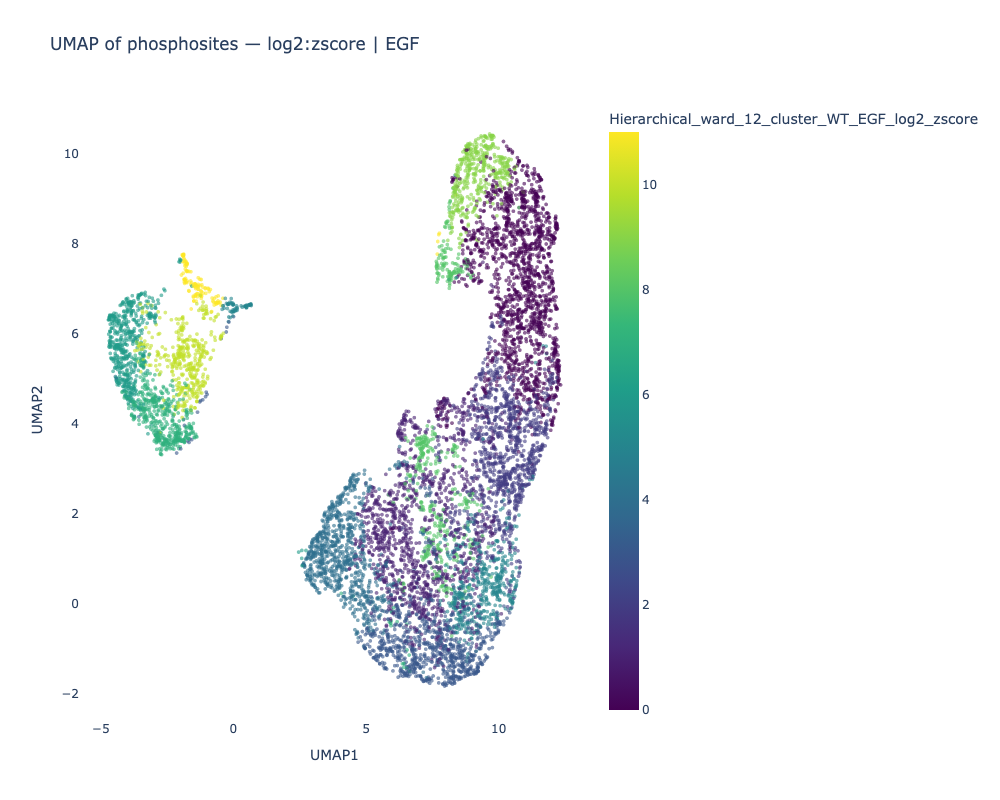

In [20]:
fig, umap_df = plot_sites_umap_interactive(df_clustered,
                                           cell_lines   = CELL_LINES,
                                           conditions   = CONDITIONS,
                                           data_type    = DATA_TYPE,
                                           exclude_full = EXCLUDE_FULL,
                                           color_col    = CLUSTER_COL,
                                           hover_cols   = None,
                                           n_neighbors  = 15,
                                           min_dist     = 0.1,
                                           random_state = 42,
                                           figsize      = (1000, 800),
                                           title        = None,)
fig.show()

# Constrained merging — restricting the clustering after seeing it

This is the section the notebook exists for. Having seen the cluster profiles, their sizes
and their QC scores, you can now **collapse clusters that share a parental node**.

### Why this is a legitimate operation, not fudging the result

Every cluster produced by cutting a tree *is* the set of leaves under one node. So if two
clusters sit under a common parent, their union is **exactly that parent node** — a cluster
the model already contains, one level up. Merging them therefore:

- requires no re-clustering and introduces no new approximation;
- moves no site anywhere except into the union of the two;
- leaves the result a valid cut of the tree, so it can be inspected and merged again.

What you are really doing is choosing a **non-uniform cut**: deeper in the parts of the
tree that show real structure, shallower where the tree separated clusters only marginally.
A single global k forces the same depth everywhere, which is exactly why it produces both
over-split and under-split clusters at the same time.

Merging clusters that do **not** share a parent breaks this property — the result is no
longer a subtree and no further tree operation is defined on it. `merge_clusters()`
refuses by default; `allow_non_sibling=True` forces it, with a warning.

## The cluster-level dendrogram

This is the figure to read before deciding anything. Each leaf is one cluster (annotated
with its site count) and each internal node is drawn at the **true merge distance from the
site-level tree**. Two leaves joined low down are clusters the data barely separates.

(Contrast with `compute_centroid_linkage()` in the KMeans notebook, which re-clusters the
centroids and therefore invents a hierarchy the model never had. Here the heights are the
model's own.)

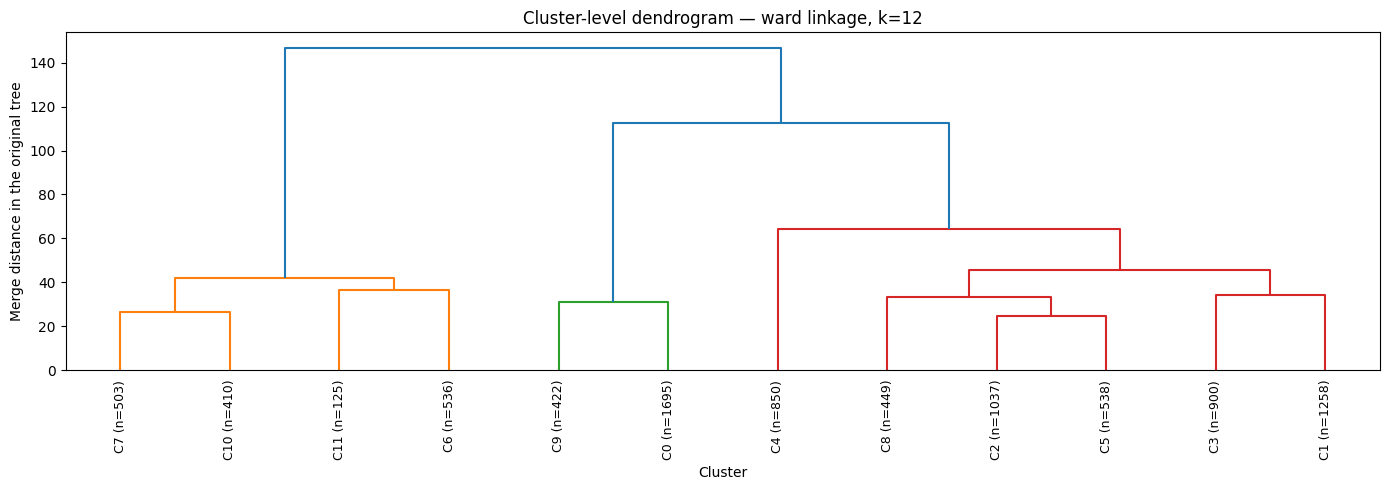

In [21]:
fig, ax, Z_clusters = plot_cluster_tree(Z                 = result.Z,
                                        labels            = result.labels,
                                        merge_height_line = None,   # set a height to preview a bulk merge
                                        figsize           = (14, 5),
                                        title             = f"Cluster-level dendrogram — {LINKAGE_METHOD} linkage, k={K_FINAL}",)
plt.show()

## Which merges are legal, and what do they cost?

Every row is a set of clusters that shares a parental node. Sorted by `merge_height`
ascending, so the **cheapest merges come first** — those join clusters the tree could
barely tell apart.

- `is_sibling_pair=True` — a direct sibling pair, the simplest merge.
- `is_sibling_pair=False` — a larger group formed higher up (e.g. one cluster joining an
  already-merged pair). Also legal, also exact.
- `centroid_distance` — Euclidean distance between the two cluster mean profiles. Answers
  the practical question: *would the merged mean profile even look different?* A small
  value means you would not be able to tell the two clusters apart in the profile plot.

Cross-reference this with `sil_table` above: a cluster with a near-zero silhouette that
also has a low-height sibling is the clearest merge case you can make.

In [22]:
mergeable = mergeable_cluster_groups(Z         = result.Z,
                                     labels    = result.labels,
                                     pairs_only = False,
                                     centroids  = result.centroids,)
mergeable

,clusters,n_clusters,merge_height,merged_size,is_sibling_pair,centroid_distance
0,"(2, 5)",2,24.571078,1575,True,0.923143
1,"(7, 10)",2,26.490445,913,True,1.246332
2,"(0, 9)",2,31.104837,2117,True,1.196554
3,"(2, 5, 8)",3,33.191016,2024,False,NaN
4,"(1, 3)",2,34.051967,2158,True,1.051215
5,"(6, 11)",2,36.366133,661,True,2.554144
6,"(6, 7, 10, 11)",4,41.908877,1574,False,NaN
7,"(1, 2, 3, 5, 8)",5,45.724611,4182,False,NaN
8,"(1, 2, 3, 4, 5, 8)",6,64.261518,5032,False,NaN
9,"(0, 1, 2, 3, 4, 5, 8, 9)",8,112.562409,7149,False,NaN


In [23]:
# Direct sibling pairs only — the shortlist
mergeable_cluster_groups(Z          = result.Z,
                         labels     = result.labels,
                         pairs_only = True,
                         centroids  = result.centroids,)

,clusters,n_clusters,merge_height,merged_size,is_sibling_pair,centroid_distance
0,"(2, 5)",2,24.571078,1575,True,0.923143
1,"(7, 10)",2,26.490445,913,True,1.246332
2,"(0, 9)",2,31.104837,2117,True,1.196554
3,"(1, 3)",2,34.051967,2158,True,1.051215
4,"(6, 11)",2,36.366133,661,True,2.554144


## Option A — rule-based proposals

Two rules that are defensible in writing:

- **`min_cluster_size`** — merge any cluster smaller than this into its sibling. Small
  clusters are rarely interpretable, cannot support enrichment testing (Fisher needs
  counts), and are the usual by-product of hierarchical methods shaving off outliers.
- **`max_height`** — merge sibling pairs whose parent sits below this merge distance.
  Keeping such clusters apart claims a distinction the data does not support.

Overlapping proposals are resolved with union-find, so the returned groups are disjoint
and can all be applied in one call.

In [24]:
proposed_merges = suggest_merges(Z                = result.Z,
                                 labels           = result.labels,
                                 max_height       = MERGE_MAX_HEIGHT,
                                 min_cluster_size = MERGE_MIN_CLUSTER_SIZE,
                                 verbose          = True,)
proposed_merges

1 merge group(s) proposed (12 -> 11 clusters):
  merge [2, 5] -> 1575 sites

Reasons per sibling pair:
  (2, 5): merge height 24.571 <= 25.0


[[2, 5]]

## Option B — merges you choose by hand

Override `proposed_merges` with your own groups after reading the dendrogram, the profile
plots and the `mergeable` table. Each group must appear in the `clusters` column of
`mergeable` — otherwise `merge_clusters()` raises and tells you so.

In [25]:
# Edit and uncomment to take manual control:
# proposed_merges = [[2, 5],
#                    [7, 10],]
print(f"Merges to apply: {proposed_merges}")

Merges to apply: [[2, 5]]


## Apply the merges

The original labels are kept — the merged labels go into a **new column** (`MERGED_COL`),
so the two can be compared and the merge can be undone by simply ignoring the new column.
Surviving clusters are renumbered by decreasing size.

In [26]:
df_clustered, merge_mapping = merge_clusters(df                = df_clustered,
                                             cluster_column    = CLUSTER_COL,
                                             merges            = proposed_merges,
                                             Z                 = result.Z,
                                             new_column        = MERGED_COL,
                                             allow_non_sibling = False,
                                             relabel           = True,
                                             verbose           = True,)

merged_labels = df_clustered[MERGED_COL].to_numpy()

12 -> 11 clusters, written to 'Hierarchical_ward_12_cluster_WT_EGF_log2_zscore_merged'
  merged [2, 5] -> cluster 1

New cluster sizes:
0     1695
1     1575
2     1258
3      900
4      850
5      536
6      503
7      449
8      422
9      410
10     125
Name: count, dtype: int64


## Option C — collapse the whole tree at one height

Instead of naming groups, cut the **cluster-level** tree at a chosen merge distance: every
sibling merge below that height is applied at once. The fastest way to answer *"what if I
only keep the structure that separates at distance > h?"*. Read the height off the
cluster-level dendrogram above.

The result is still a valid cut of the original tree, so it stays fully mergeable.

In [27]:
# MERGE_HEIGHT = 40.0
#
# merged_labels_by_height, height_mapping = merge_clusters_by_height(Z       = result.Z,
#                                                                    labels  = result.labels,
#                                                                    height  = MERGE_HEIGHT,
#                                                                    verbose = True,)
# df_clustered[f"{CLUSTER_COL}_h{MERGE_HEIGHT}"] = merged_labels_by_height
#
# fig, ax, _ = plot_cluster_tree(Z                 = result.Z,
#                                labels            = result.labels,
#                                merge_height_line = MERGE_HEIGHT,
#                                title             = f"Preview of the cut at height {MERGE_HEIGHT}",)
# plt.show()

## QC after merging

Re-run the same diagnostics on the merged labels. What to expect and how to read it:

- **Silhouette should not collapse.** Merging two genuinely-overlapping clusters usually
  *raises* the mean silhouette, because the sites that were sitting on the boundary
  between them are no longer being penalised for it. A merge that clearly *lowers* the
  silhouette was joining two real, separable shapes — reconsider it.
- **Nearest-centroid agreement usually rises**, since there are fewer competing centroids.
- **The profile plots are the final arbiter.** If the merged cluster's mean profile is a
  smeared average of two visibly different shapes, undo the merge regardless of the metrics.

Because the merged labels are still a valid tree cut, `plot_cluster_tree()` works on them
and you can iterate: merge, inspect, merge again.

### A worked example of a merge you should *reject*

Switch the Parameters cell to `MERGE_MAX_HEIGHT = None`, `MERGE_MIN_CLUSTER_SIZE = 200` and
re-run this section. The small-cluster rule then proposes merging clusters **6 and 11** —
and the QC below gets *worse*: the mean silhouette drops and the merged cluster lands at a
**negative** silhouette, i.e. most of its sites are now closer to some other cluster.

The warning was visible before running anything. In the `mergeable` table that pair has the
**largest `centroid_distance` of all sibling pairs** (~2.55, against ~0.92 for the cheapest
pair) and the highest `merge_height` — the tree separated them clearly and only puts them
together because they happen to be each other's nearest remaining neighbour. A cluster being
small is a reason to *look*, never on its own a reason to merge. Check the height and the
centroid distance before accepting any proposal.

In [28]:
merged_centroids = cluster_centroids(result.X, merged_labels)
merged_distances = distances_to_centroids(result.X_flat, merged_centroids)

sil_before = silhouette_per_cluster(result.X_flat, result.labels,  sample_size=SILHOUETTE_SAMPLE, random_state=0)
sil_after  = silhouette_per_cluster(result.X_flat, merged_labels,  sample_size=SILHOUETTE_SAMPLE, random_state=0)

agree_before, _ = assignment_agreement(result.distances_to_centroids, result.labels)
agree_after,  _ = assignment_agreement(merged_distances,              merged_labels)

print(f"clusters                : {len(np.unique(result.labels))} -> {len(np.unique(merged_labels))}")
print(f"mean silhouette         : {sil_before['mean_silhouette'].mean():.4f} -> {sil_after['mean_silhouette'].mean():.4f}")
print(f"worst cluster silhouette: {sil_before['mean_silhouette'].min():.4f} -> {sil_after['mean_silhouette'].min():.4f}")
print(f"smallest cluster        : {sil_before['n_sites'].min()} -> {sil_after['n_sites'].min()} (in the silhouette subsample)")
print(f"nearest-centroid agreement: {agree_before:.1%} -> {agree_after:.1%}")
print(f"\nPer-cluster silhouette after merging (worst first):")
sil_after

clusters                : 12 -> 11
mean silhouette         : 0.1432 -> 0.1542
worst cluster silhouette: -0.0327 -> -0.0095
smallest cluster        : 47 -> 47 (in the silhouette subsample)
nearest-centroid agreement: 78.7% -> 79.4%

Per-cluster silhouette after merging (worst first):


,cluster,n_sites,mean_silhouette,median_silhouette,frac_negative
0,7,188,-0.009510,-0.024263,0.563830
1,2,580,0.048465,0.057217,0.375862
2,9,180,0.059066,0.083140,0.388889
3,1,724,0.091657,0.111290,0.256906
4,10,47,0.107096,0.100636,0.234043
5,5,228,0.145230,0.185514,0.210526
6,0,798,0.176167,0.206979,0.186717
7,3,407,0.214041,0.244710,0.137592
8,4,415,0.217390,0.236069,0.127711
9,6,232,0.300027,0.326844,0.043103


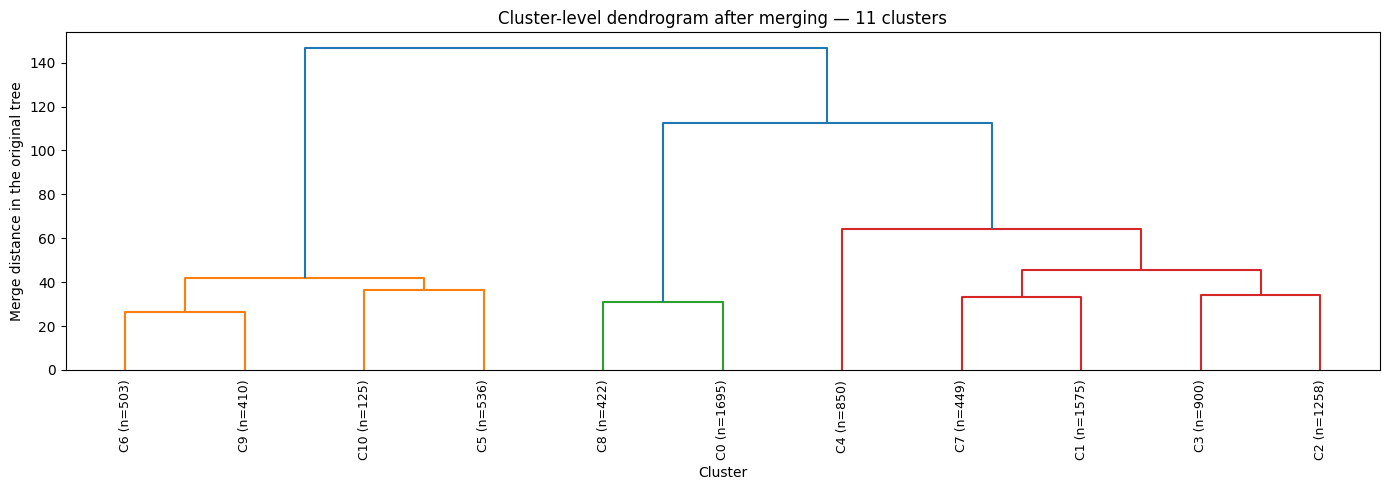

In [29]:
fig, ax, _ = plot_cluster_tree(Z       = result.Z,
                               labels  = merged_labels,
                               figsize = (14, 5),
                               title   = f"Cluster-level dendrogram after merging — {len(np.unique(merged_labels))} clusters",)
plt.show()

 Plot not saved


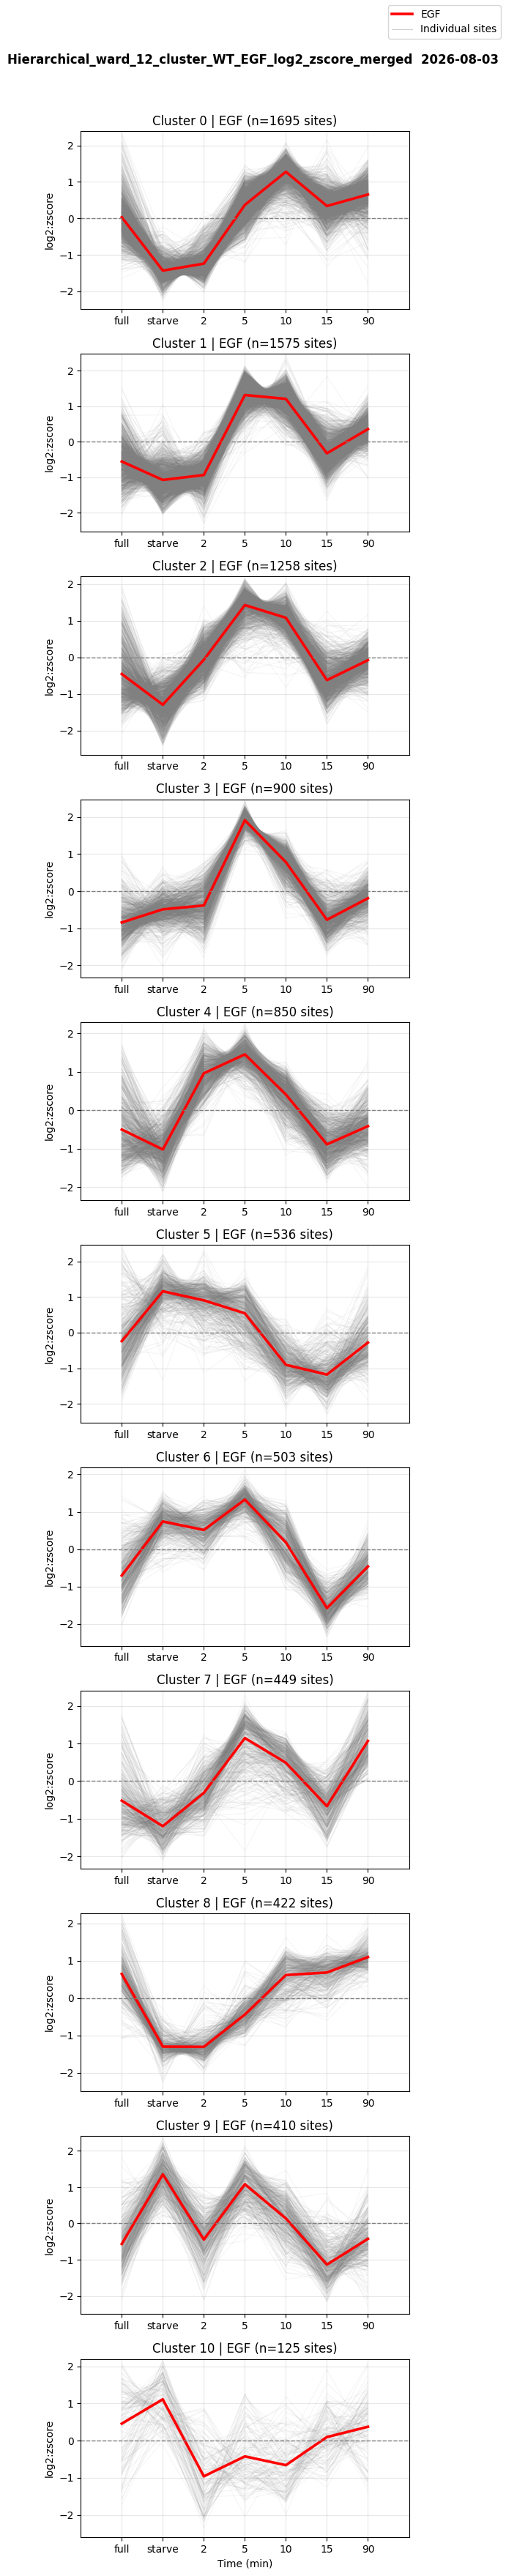

In [30]:
clusters_plot_linear_mutants(df                  = df_clustered,
                             cluster_column      = MERGED_COL,
                             data_type           = DATA_TYPE,
                             cell_lines          = CELL_LINES,
                             conditions          = CONDITIONS,
                             colors              = {"_EGF_": "red", "_INS_": "blue", "_EGFnINS_": "fuchsia"},
                             panel_by            = "condition",
                             plot_different_data = True,
                             legend              = None,
                             saving_path         = "",
                             saving_info         = "",
                             save_pdf            = False,
                             save_png            = False,
                             plot_close          = False,
                             fit_y_lims          = False,
                             grey_alpha          = 0.08,
                             grey_lw             = 0.8,
                             mean_lw             = 2.6,)

## Substructure diagnostic — the opposite check

Merging asks "are these two clusters really one?". This asks the reverse: **does one
cluster hide two shapes?** For a chosen cluster it plots the distance-to-centroid histogram
with 1- and 2-component Gaussian fits (a much lower 2-component BIC hints at substructure),
then compares the cluster centroid against the mean of its *close* half vs its *far* half.

Treat "2 components preferred" as real substructure worth splitting **only** when the
close-half and far-half mean curves also differ in *shape* — a low 2-component BIC alone
often just means a tight core plus a diffuse halo of outliers.

In this notebook the fix for genuine substructure is easy: cut the tree deeper (raise
`K_FINAL`) and merge back the parts you do not want, rather than accepting one global k.

`diagnose_cluster_substructure()` expects an `AdaptiveClusteringResult`. `HierarchicalResult`
already exposes every attribute it reads (`labels`, `X`, `centroids`, `cluster_sizes`,
`params`) — the only adjustment is flattening the centroids.

*Note on the histogram y-axis:* it is drawn with `density=True`, so bar height is
`count / (total × bin_width)` — a probability **density**, not a site count. Area sums to 1,
which is why bars can exceed 1 and why the fitted Gaussian curves are directly comparable
to the bars.

Cluster 0: 1695 members
  BIC (1 component): 1371.1
  BIC (2 components): 889.9
  Preferred: 2 component(s) (sub-structure likely)


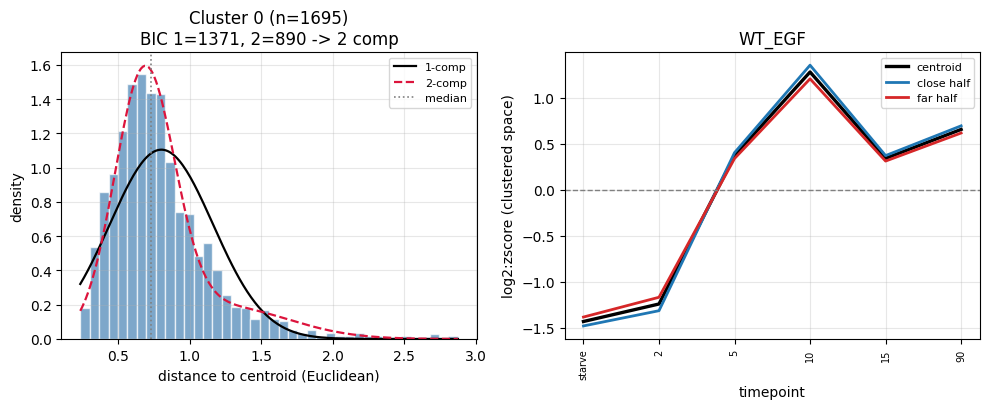

Cluster 0: BIC 1-comp=1371.1  2-comp=889.9  -> preferred 2 component(s)

Cluster 1: 1575 members
  BIC (1 component): 1042.4
  BIC (2 components): 757.5
  Preferred: 2 component(s) (sub-structure likely)


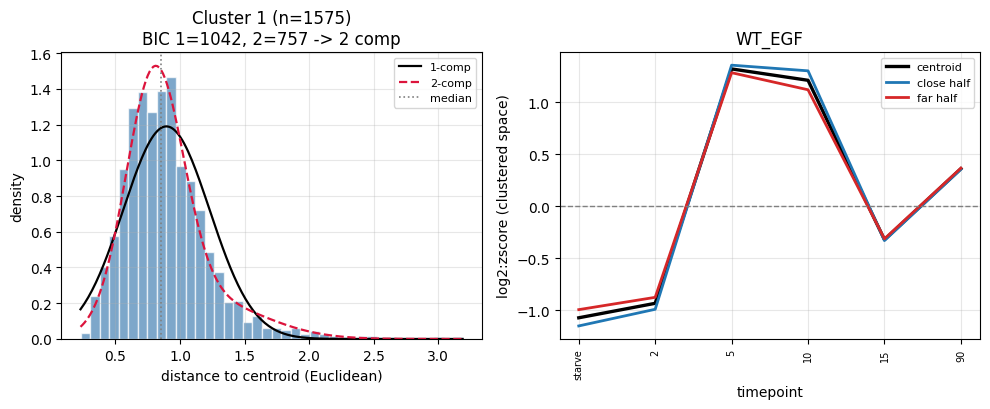

Cluster 1: BIC 1-comp=1042.4  2-comp=757.5  -> preferred 2 component(s)

Cluster 2: 1258 members
  BIC (1 component): 859.9
  BIC (2 components): 591.9
  Preferred: 2 component(s) (sub-structure likely)


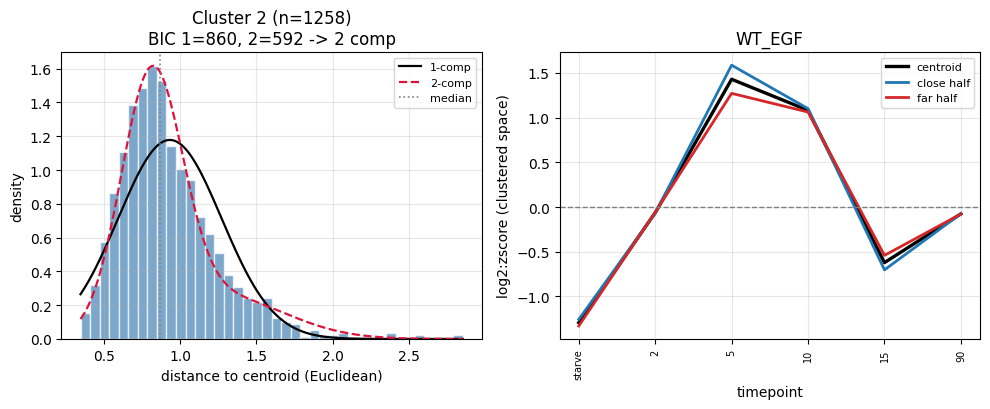

Cluster 2: BIC 1-comp=859.9  2-comp=591.9  -> preferred 2 component(s)

Cluster 3: 900 members
  BIC (1 component): 594.2
  BIC (2 components): 483.2
  Preferred: 2 component(s) (sub-structure likely)


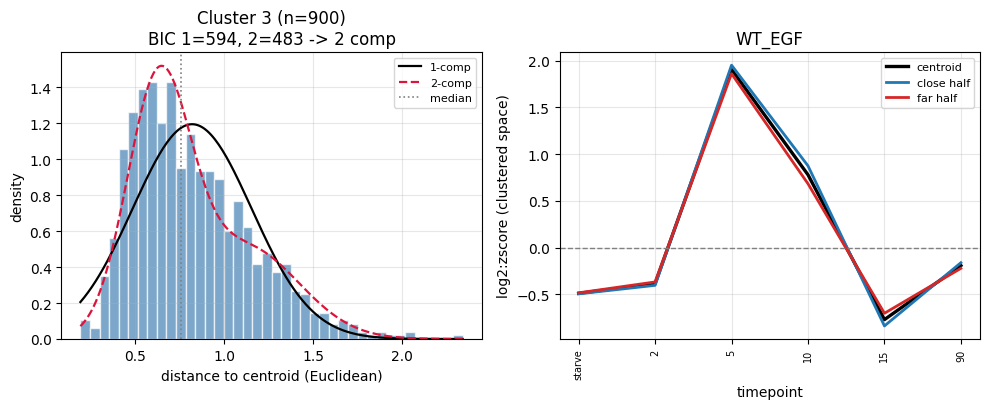

Cluster 3: BIC 1-comp=594.2  2-comp=483.2  -> preferred 2 component(s)

Cluster 4: 850 members
  BIC (1 component): 552.7
  BIC (2 components): 469.8
  Preferred: 2 component(s) (sub-structure likely)


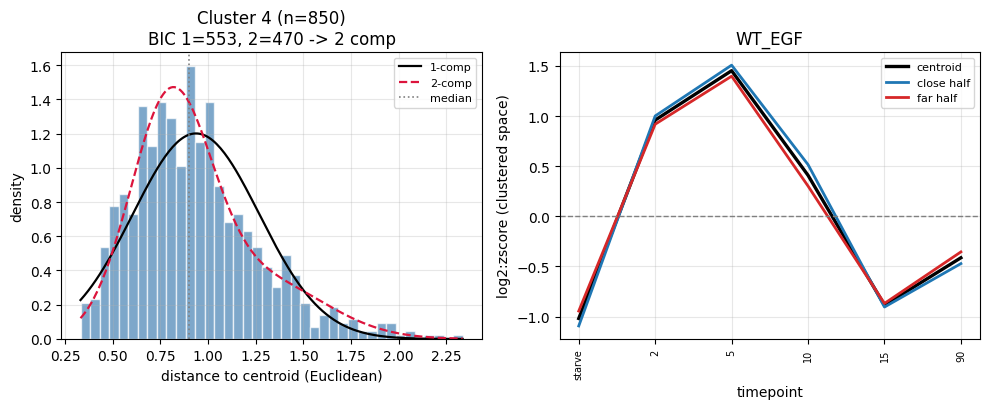

Cluster 4: BIC 1-comp=552.7  2-comp=469.8  -> preferred 2 component(s)

Cluster 5: 536 members
  BIC (1 component): 667.8
  BIC (2 components): 548.8
  Preferred: 2 component(s) (sub-structure likely)


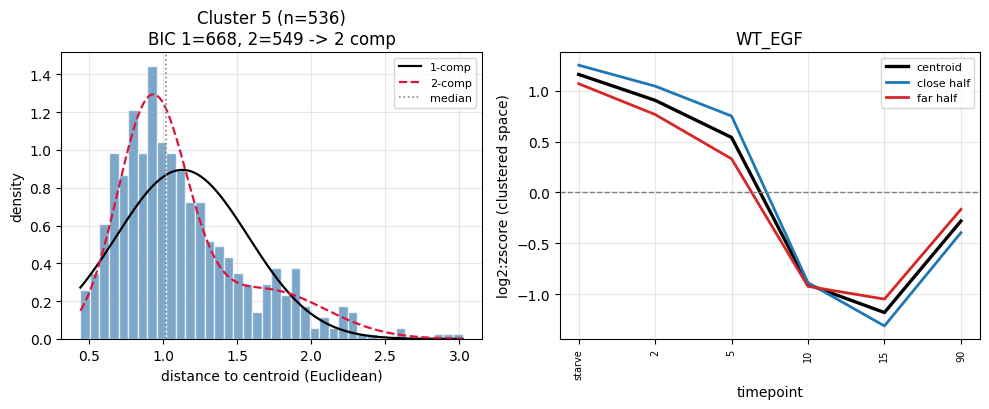

Cluster 5: BIC 1-comp=667.8  2-comp=548.8  -> preferred 2 component(s)

Cluster 6: 503 members
  BIC (1 component): 157.7
  BIC (2 components): 141.9
  Preferred: 2 component(s) (sub-structure likely)


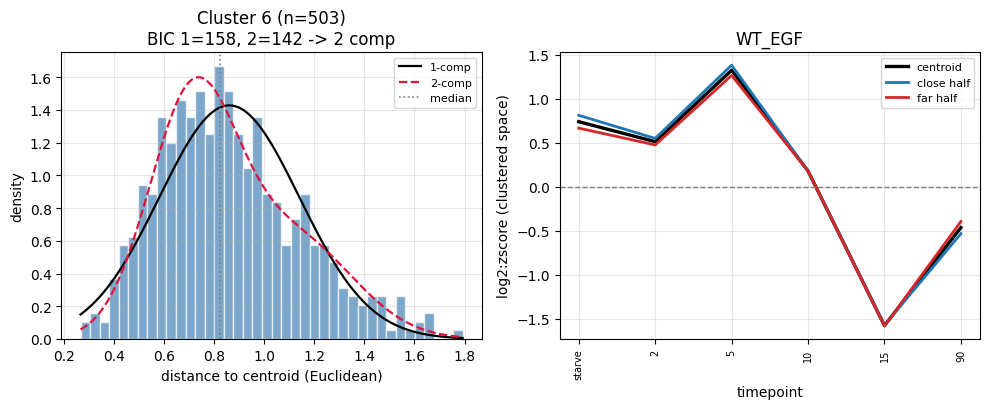

Cluster 6: BIC 1-comp=157.7  2-comp=141.9  -> preferred 2 component(s)

Cluster 7: 449 members
  BIC (1 component): 465.4
  BIC (2 components): 388.1
  Preferred: 2 component(s) (sub-structure likely)


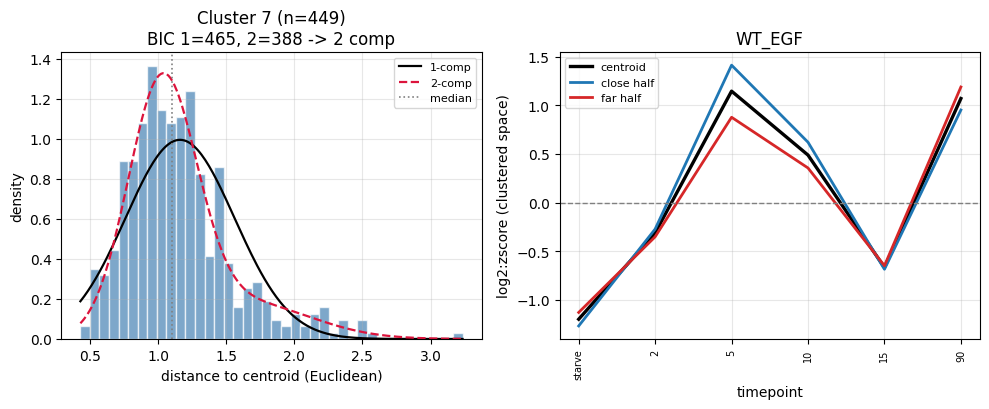

Cluster 7: BIC 1-comp=465.4  2-comp=388.1  -> preferred 2 component(s)

Cluster 8: 422 members
  BIC (1 component): 287.1
  BIC (2 components): 176.4
  Preferred: 2 component(s) (sub-structure likely)


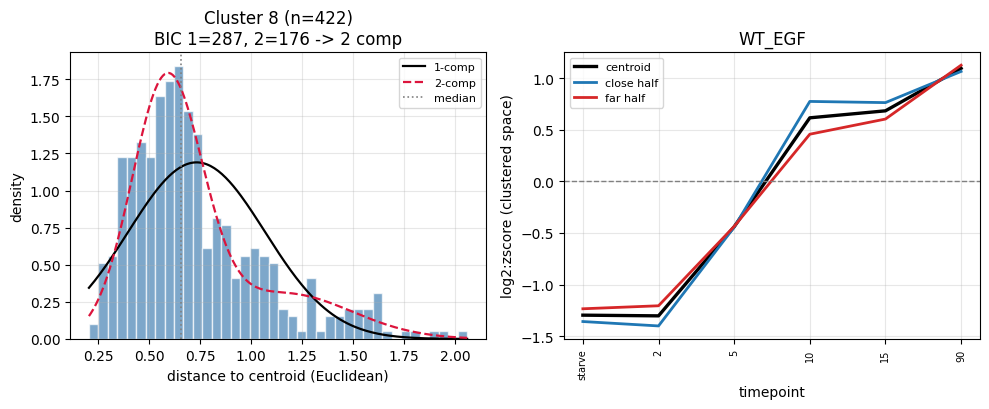

Cluster 8: BIC 1-comp=287.1  2-comp=176.4  -> preferred 2 component(s)

Cluster 9: 410 members
  BIC (1 component): 472.9
  BIC (2 components): 441.4
  Preferred: 2 component(s) (sub-structure likely)


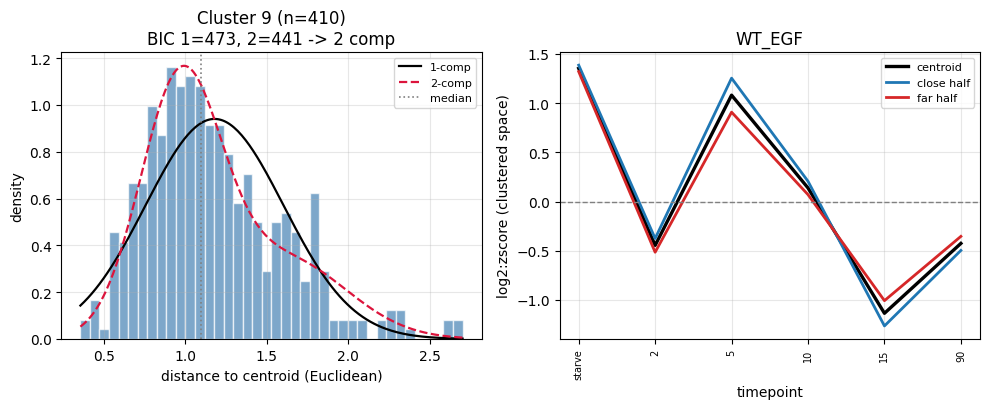

Cluster 9: BIC 1-comp=472.9  2-comp=441.4  -> preferred 2 component(s)

Cluster 10: 125 members
  BIC (1 component): 147.6
  BIC (2 components): 156.9
  Preferred: 1 component(s) (looks unimodal)


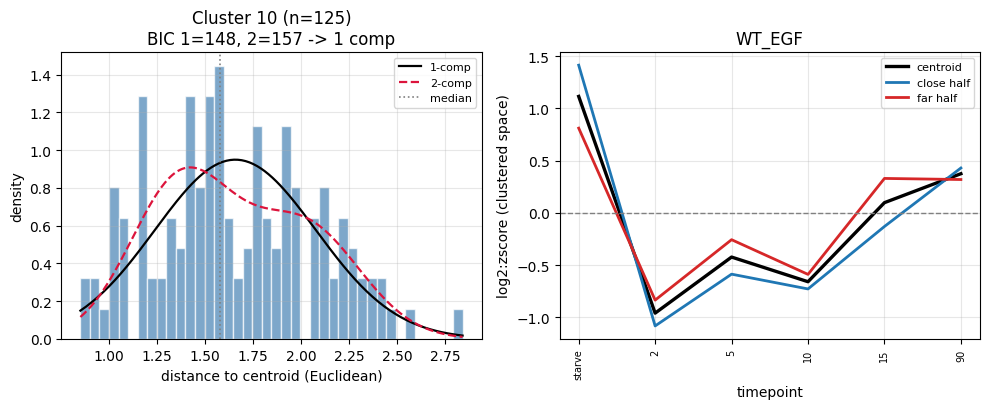

Cluster 10: BIC 1-comp=147.6  2-comp=156.9  -> preferred 1 component(s)



In [31]:
from types import SimpleNamespace
from src.adaptive_clustering import diagnose_cluster_substructure

diag_result = SimpleNamespace(labels        = merged_labels,
                              X             = result.X,
                              centroids     = merged_centroids.reshape(merged_centroids.shape[0], -1),
                              cluster_sizes = pd.Series(merged_labels).value_counts().sort_index().to_dict(),
                              params        = {"time_series_length": N_TIMEPOINTS,
                                               "column_selection":   result.params["column_selection"],
                                               "transpose":          True,
                                               "stoichiometry":      None,
                                               "data_type":          DATA_TYPE,},)

# Inspect every cluster (edit the loop to a single label, e.g. [3], to focus on one).
for lbl in sorted(diag_result.cluster_sizes):
    diag = diagnose_cluster_substructure(diag_result,
                                         cluster_label = lbl,)
    plt.show()
    print(f"Cluster {lbl}: BIC 1-comp={diag['bic_1']:.1f}  2-comp={diag['bic_2']:.1f}  "
          f"-> preferred {diag['preferred_n_components']} component(s)\n")

## Comparison with the existing KMeans labels

The hme1_2 table already carries six KMeans label columns (see CLAUDE.md, *Cluster-label
columns*). Since the filtering and column selection here are identical, the two partitions
can be compared directly with the **Adjusted Rand Index** — 1.0 = identical partitions,
~0 = no more agreement than chance. ARI is invariant to label permutation, so it does not
care that the two methods number their clusters differently.

Rough reading: **ARI > 0.5** means the two methods largely recover the same structure and
the choice between them is a matter of convenience; **ARI < 0.3** means they disagree
substantially, and the disagreement itself is worth investigating before either partition
is used as ground truth downstream.

Note the caveat from CLAUDE.md: `KMeans_adaptive_*_EGF_*` labels were computed from **all
three conditions jointly**, while `KMeans_11_*` used **EGF only**. Only the latter is an
apples-to-apples comparison when `CONDITIONS = ["_EGF_"]`.

In [32]:
kmeans_cols = [c for c in df_clustered.columns if c.startswith("KMeans")]

rows = []
for km_col in kmeans_cols:
    valid = df_clustered[km_col].notna()
    rows.append({"kmeans_column":  km_col,
                 "n_kmeans_clusters": int(df_clustered.loc[valid, km_col].nunique()),
                 "ARI_vs_hierarchical":        adjusted_rand_score(df_clustered.loc[valid, km_col],
                                                                   df_clustered.loc[valid, CLUSTER_COL]),
                 "ARI_vs_hierarchical_merged": adjusted_rand_score(df_clustered.loc[valid, km_col],
                                                                   df_clustered.loc[valid, MERGED_COL]),})

pd.DataFrame(rows).sort_values("ARI_vs_hierarchical", ascending=False)

,kmeans_column,n_kmeans_clusters,ARI_vs_hierarchical,ARI_vs_hierarchical_merged
5,KMeans_11_cluster_WT_EGF_log2_zscore,10,0.433790,0.444051
4,KMeans_11_cluster_WT_EGF_log2_scaled,10,0.378695,0.372228
2,KMeans_adaptive_cluster_WT_EGF_log2_zscore,10,0.327184,0.329825
3,KMeans_11_cluster_WT_EGF_log2_FC,11,0.216256,0.212889
1,KMeans_adaptive_cluster_WT_EGF_log2_scaled,10,0.184351,0.216178
0,KMeans_adaptive_cluster_WT_EGF_log2_FC,11,0.095806,0.116157


### Where exactly do the two methods disagree?

The cross-tabulation shows how the sites of each hierarchical cluster are distributed over
the KMeans clusters. A near-diagonal table (after reordering) means agreement; a
hierarchical cluster spread evenly across several KMeans clusters is a site set the two
methods genuinely see differently.

KMeans_11_cluster_WT_EGF_log2_zscore,0,1,2,3,4,5,6,7,8,9
Hierarchical_ward_12_cluster_WT_EGF_log2_zscore_merged,,,,,,,,,,
0,583,0,0,15,1051,3,0,23,0,20
1,4,0,0,887,391,128,0,105,3,57
2,3,107,0,120,24,439,0,557,0,8
3,0,20,0,118,0,715,21,12,0,14
4,0,730,8,0,0,65,4,32,0,11
5,0,2,490,0,0,0,18,0,26,0
6,0,4,65,0,0,21,413,0,0,0
7,27,1,0,30,6,45,0,56,0,284
8,421,0,0,0,1,0,0,0,0,0


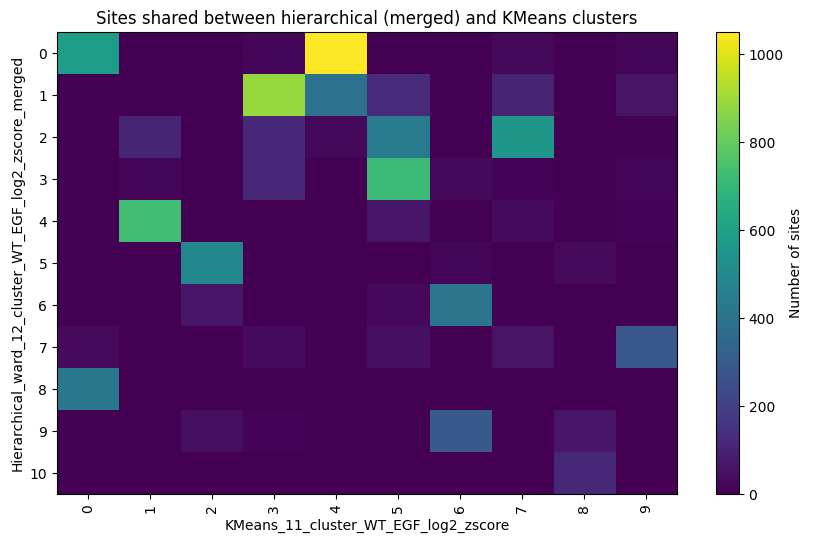

In [33]:
KM_COMPARE_COL = "KMeans_11_cluster_WT_EGF_log2_zscore"   # EGF-only clustering — the fair comparison

if KM_COMPARE_COL in df_clustered.columns:
    crosstab = pd.crosstab(df_clustered[MERGED_COL],
                           df_clustered[KM_COMPARE_COL],)
    display(crosstab)

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(crosstab.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(crosstab.shape[1]))
    ax.set_xticklabels(crosstab.columns, rotation=90)
    ax.set_yticks(range(crosstab.shape[0]))
    ax.set_yticklabels(crosstab.index)
    ax.set_xlabel(KM_COMPARE_COL)
    ax.set_ylabel(MERGED_COL)
    ax.set_title("Sites shared between hierarchical (merged) and KMeans clusters")
    fig.colorbar(im, ax=ax, label="Number of sites")
    plt.show()
else:
    print(f"{KM_COMPARE_COL} not present in this dataset — skipping.")

## Save

Processed data is saved as `.tsv` (project rule). The filename carries the linkage method
and k so runs do not overwrite each other. **Uncomment to write.**

In [34]:
# from datetime import date
#
# OUT_PATH = (f"../../notebooks/03_clustering/Data_clustered/"
#             f"{date.today():%Y%m%d}_hTERT_HME1_2_hierarchical_{LINKAGE_METHOD}_k{K_FINAL}.tsv")
#
# df_clustered.to_csv(OUT_PATH, sep="\t", index=False)
# print(f"Written: {OUT_PATH}  ({df_clustered.shape[0]} sites, "
#       f"columns added: {CLUSTER_COL}, {MERGED_COL})")